<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/LucasCNN_MODEL1(don't_change)_OF_TEST_CNN_Example_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [486]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cuda



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [487]:
def evaluate_classifier(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.shape[0]
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += X_batch.shape[0]
    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc

def train_classifier(model, train_loader, test_loader=None, epochs=5, learning_rate=1e-3, verbose=True, enable_scheduler=False):
    # Train a PyTorch classifier using cross-entropy loss.
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    scheduler = None
    if enable_scheduler:
        # Add a learning rate scheduler (StepLR)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # Reduce LR by 0.5 every 5 epochs

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }


    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = X_batch.shape[0]
            total_loss += loss.item() * batch_size
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += batch_size

        if scheduler:
            scheduler.step()

        train_loss = total_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        current_lr = optimizer.param_groups[0]['lr']

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"lr = {current_lr:.6f}, " # Added learning rate
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}, "
                    f"test loss = {test_loss:.4f}, test acc = {test_acc:.4f}"
                )

        else:
            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"lr = {current_lr:.6f}, " # Added learning rate
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}"
                )

    return history


## 4. Helper Function: Plot Training Curves


In [488]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()



# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D CNN can be applied to sequential data such as:

- sensor measurements,
- financial signals,
- ECG or EEG recordings,
- audio waveforms,
- machine monitoring data,
- traffic or demand data.

A 1D convolutional layer slides filters along the time axis.

For PyTorch `nn.Conv1d`, the input shape is:

\[
N \times C \times L,
\]

where:

- `N` is the batch size,
- `C` is the number of input channels,
- `L` is the sequence length.

For a single univariate time series, `C = 1`.



## 10. Generate a Synthetic Time-Series Dataset

We will create a three-class time-series classification problem.

Each signal has length 100.

The classes are:

- Class 0: low-frequency sine wave,
- Class 1: high-frequency sine wave,
- Class 2: square-wave-like signal.

Noise is added so the classification task is not completely trivial.


In [489]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [490]:
from re import X
ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']


#initial definitions
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


(1000, 12, 2500)
(1000,)



## 11. Visualize Example Time Series


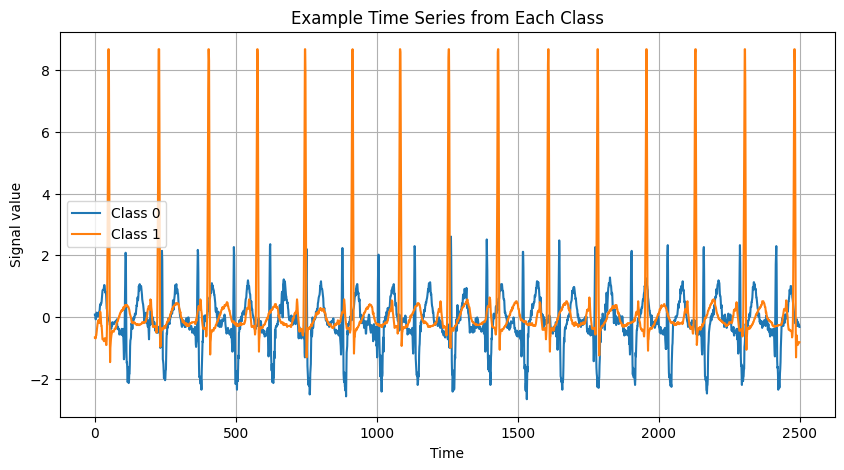

In [491]:
t = np.arange(X_ts.shape[2]) # Define the time axis

plt.figure(figsize=(10, 5))
# Iterate only over the unique class labels present in y_ts
for class_label in np.unique(y_ts):
    # Find the index of the first occurrence of the current class_label
    idx = np.where(y_ts == class_label)[0][0]
    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")

plt.xlabel("Time")
plt.ylabel("Signal value")
plt.title("Example Time Series from Each Class")
plt.grid(True)
plt.legend()
plt.show()


## 12. Create PyTorch DataLoaders for Time Series


In [492]:

X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


torch.Size([32, 12, 2500])
Time-series training samples: 800
Time-series test samples: 200



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [493]:
class TimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — compress heavily with large kernel
            nn.Conv1d(in_channels, 8, kernel_size=13, padding=6),
            nn.ReLU(),
            nn.Dropout(0.2), # Reduced dropout
            nn.AvgPool1d(kernel_size=5),   # 2500 → 500

            # Block 2 — compress again
            nn.Conv1d(8, 12, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Dropout(0.2), # Reduced dropout
            nn.AvgPool1d(kernel_size=5),   # 500 → 100

            # Block 3 — final compression
            nn.Conv1d(12, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5),   # 100 → 20

            # Block 4 — final compression
            nn.Conv1d(16, 20, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5),   # 20 → 4


        )

        # 16 filters * 20 timesteps = 320 — much smaller than before (9984)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(20 * 4, 20),
            nn.ReLU(),
            nn.Dropout(0.2), # Keep dropout in classifier
            nn.Linear(20, num_classes),
        )

    def forward(self, x):
        x = self.features(x);
        x = self.classifier(x);
        return x

ts_model = TimeSeriesConvNet(sequence_length=2500, num_classes=2);
print(ts_model);

TimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(12, 8, kernel_size=(13,), stride=(1,), padding=(6,))
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (4): Conv1d(8, 12, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (8): Conv1d(12, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): ReLU()
    (10): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (11): Conv1d(16, 20, kernel_size=(5,), stride=(1,), padding=(2,))
    (12): ReLU()
    (13): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=80, out_features=20, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=20, out_features=2, bias=True)
  )
)


### 13.1 Define a Simplified 1D CNN for Time-Series Classification

Here is an alternative model architecture, `SimplifiedTimeSeriesConvNet`, which uses fewer convolutional blocks and Max Pooling for faster downsampling. The goal is to demonstrate a different layout while keeping the overall complexity manageable.

In [494]:
class SimplifiedTimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(in_channels, 32, kernel_size=15, padding=7), # Larger kernel to capture more context
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5),   # 2500 -> 500
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5),   # 500 -> 100
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5),   # 100 -> 20
            nn.Dropout(0.2)
        )

        # Calculate the size of the flattened features
        # This requires a dummy pass or careful calculation
        # After 3 MaxPool1d(5), sequence length becomes 2500 / 5 / 5 / 5 = 20
        # Number of output channels is 128 (was 64)
        final_feature_size = 128 * 20

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(final_feature_size, 64), # Adjusted to new feature size
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instantiate the new model
simplified_ts_model = SimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
print("Simplified Model Architecture:")
print(simplified_ts_model);

Simplified Model Architecture:
SimplifiedTimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(12, 32, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): ReLU()
    (6): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): ReLU()
    (10): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


### 14.1 Train the Simplified 1D CNN

Now, let's train this new, simplified model using the same training function.

Epoch 1/30: lr = 0.000300, train loss = 0.6854, train acc = 0.5337, test loss = 0.6632, test acc = 0.5450
Epoch 2/30: lr = 0.000300, train loss = 0.6423, train acc = 0.6162, test loss = 0.5794, test acc = 0.6750
Epoch 3/30: lr = 0.000300, train loss = 0.5836, train acc = 0.6837, test loss = 0.6105, test acc = 0.7150
Epoch 4/30: lr = 0.000300, train loss = 0.5684, train acc = 0.7000, test loss = 0.5149, test acc = 0.7550
Epoch 5/30: lr = 0.000150, train loss = 0.5598, train acc = 0.7125, test loss = 0.5170, test acc = 0.7450
Epoch 6/30: lr = 0.000150, train loss = 0.5376, train acc = 0.7300, test loss = 0.4811, test acc = 0.7900
Epoch 7/30: lr = 0.000150, train loss = 0.5196, train acc = 0.7400, test loss = 0.4712, test acc = 0.7900
Epoch 8/30: lr = 0.000150, train loss = 0.5140, train acc = 0.7312, test loss = 0.4925, test acc = 0.7900
Epoch 9/30: lr = 0.000150, train loss = 0.5181, train acc = 0.7425, test loss = 0.4599, test acc = 0.7800
Epoch 10/30: lr = 0.000075, train loss = 0.511

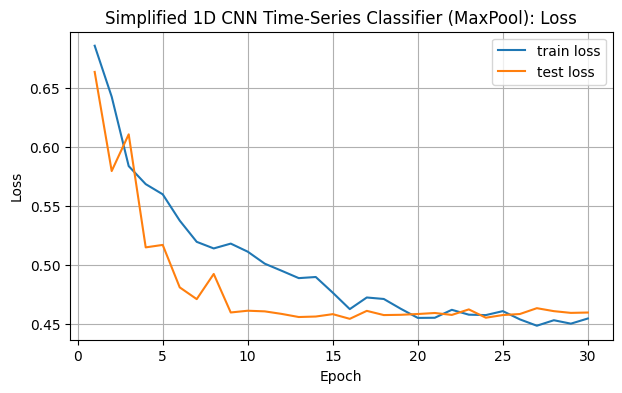

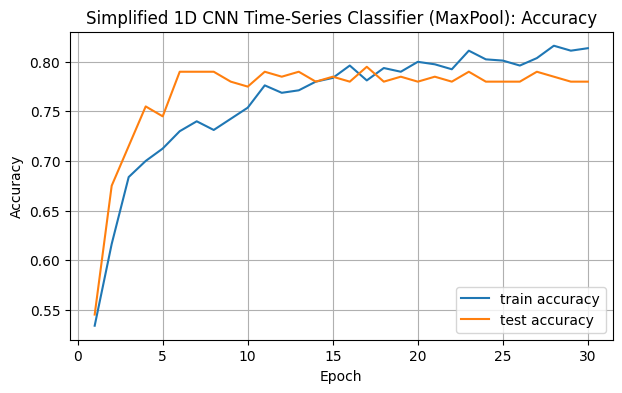

In [499]:
simplified_ts_model = SimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
simplified_ts_history = train_classifier(
    simplified_ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=30,
    learning_rate=3e-4,
    verbose=True,
    enable_scheduler=True
)

plot_history(simplified_ts_history, title="Simplified 1D CNN Time-Series Classifier (MaxPool)")

### 15.1 Improved Simplified 1D CNN Architecture

This version of the simplified model includes Batch Normalization layers and increased filter counts to potentially improve learning stability and feature extraction capabilities.

In [496]:
class ImprovedSimplifiedTimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1:
            nn.Conv1d(in_channels, 48, kernel_size=13, padding=6), # padding for kernel 13: (13-1)//2 = 6
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 2500 -> 500
            nn.Dropout(0.2),

            # Block 2:
            nn.Conv1d(48, 96, kernel_size=7, padding=3), # padding for kernel 7: (7-1)//2 = 3
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 500 -> 100
            nn.Dropout(0.2),

            # Block 3:
            nn.Conv1d(96, 192, kernel_size=5, padding=2), # padding for kernel 5: (5-1)//2 = 2
            nn.BatchNorm1d(192),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 100 -> 20
            nn.Dropout(0.2),

            # Block 4:
            nn.Conv1d(192, 384, kernel_size=3, padding=1), # padding for kernel 3: (3-1)//2 = 1
            nn.BatchNorm1d(384),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 20 -> 4
            nn.Dropout(0.2)
        )

        # Calculate the size of the flattened features
        # After 4 AvgPool1d(5), sequence length becomes 2500 -> 500 -> 100 -> 20 -> 4
        # Number of output channels is 384
        final_feature_size = 384 * 4

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(final_feature_size, 128), # Adjusted to new feature size and wider hidden layer
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instantiate the improved model
improved_ts_model = ImprovedSimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
print("Improved Simplified Model Architecture (with BatchNorm1d, AdaptiveAvgPool1d, 4 layers, filters (48,96,192,384), dropout=0.2):")
print(improved_ts_model);

Improved Simplified Model Architecture (with BatchNorm1d, AdaptiveAvgPool1d, 4 layers, filters (48,96,192,384), dropout=0.2):
ImprovedSimplifiedTimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(12, 48, kernel_size=(13,), stride=(1,), padding=(6,))
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(48, 96, kernel_size=(7,), stride=(1,), padding=(3,))
    (6): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(96, 192, kernel_size=(5,), stride=(1,), padding=(2,))
    (11): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (14): Dr

### 15.2 Train the Improved Simplified 1D CNN

Now, let's train this new, improved simplified model using the same training function.

Epoch 1/30: lr = 0.000100, train loss = 0.6550, train acc = 0.6175, test loss = 0.6449, test acc = 0.7200
Epoch 2/30: lr = 0.000100, train loss = 0.5826, train acc = 0.6900, test loss = 0.5302, test acc = 0.7700
Epoch 3/30: lr = 0.000100, train loss = 0.5683, train acc = 0.7037, test loss = 0.5179, test acc = 0.7600
Epoch 4/30: lr = 0.000100, train loss = 0.5474, train acc = 0.7338, test loss = 0.4986, test acc = 0.7750
Epoch 5/30: lr = 0.000050, train loss = 0.5274, train acc = 0.7538, test loss = 0.4657, test acc = 0.7800
Epoch 6/30: lr = 0.000050, train loss = 0.5227, train acc = 0.7362, test loss = 0.4730, test acc = 0.7800
Epoch 7/30: lr = 0.000050, train loss = 0.5082, train acc = 0.7575, test loss = 0.4737, test acc = 0.7900
Epoch 8/30: lr = 0.000050, train loss = 0.5107, train acc = 0.7488, test loss = 0.4724, test acc = 0.7800
Epoch 9/30: lr = 0.000050, train loss = 0.4981, train acc = 0.7625, test loss = 0.4630, test acc = 0.7850
Epoch 10/30: lr = 0.000025, train loss = 0.492

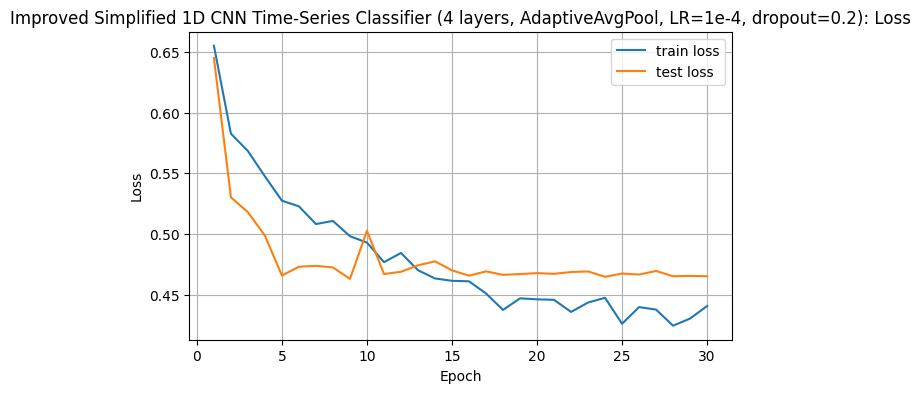

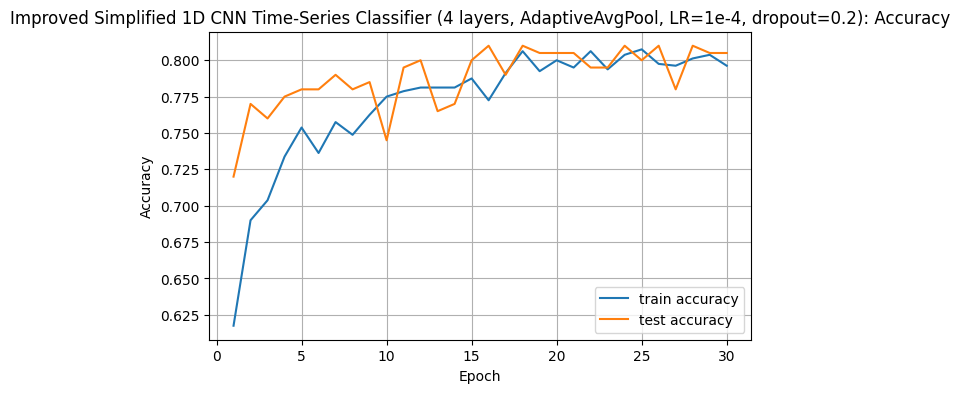

In [500]:
improved_ts_model = ImprovedSimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
improved_simplified_ts_history = train_classifier(
    improved_ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=30,
    learning_rate=1e-4,
    verbose=True,
    enable_scheduler=True
)

plot_history(improved_simplified_ts_history, title="Improved Simplified 1D CNN Time-Series Classifier (4 layers, AdaptiveAvgPool, LR=1e-4, dropout=0.2)")


## 14. Train the 1D CNN


Epoch 1/30: lr = 0.001300, train loss = 0.6981, train acc = 0.4975, test loss = 0.6813, test acc = 0.5000
Epoch 2/30: lr = 0.001300, train loss = 0.6604, train acc = 0.5413, test loss = 0.6391, test acc = 0.7200
Epoch 3/30: lr = 0.001300, train loss = 0.6411, train acc = 0.6375, test loss = 0.6134, test acc = 0.7300
Epoch 4/30: lr = 0.001300, train loss = 0.6140, train acc = 0.6987, test loss = 0.6074, test acc = 0.7250
Epoch 5/30: lr = 0.001300, train loss = 0.5874, train acc = 0.7125, test loss = 0.5148, test acc = 0.7550
Epoch 6/30: lr = 0.001300, train loss = 0.5813, train acc = 0.6825, test loss = 0.5105, test acc = 0.8100
Epoch 7/30: lr = 0.001300, train loss = 0.5808, train acc = 0.6975, test loss = 0.4945, test acc = 0.8150
Epoch 8/30: lr = 0.001300, train loss = 0.5562, train acc = 0.7312, test loss = 0.4791, test acc = 0.8050
Epoch 9/30: lr = 0.001300, train loss = 0.5547, train acc = 0.7225, test loss = 0.4790, test acc = 0.8100
Epoch 10/30: lr = 0.001300, train loss = 0.541

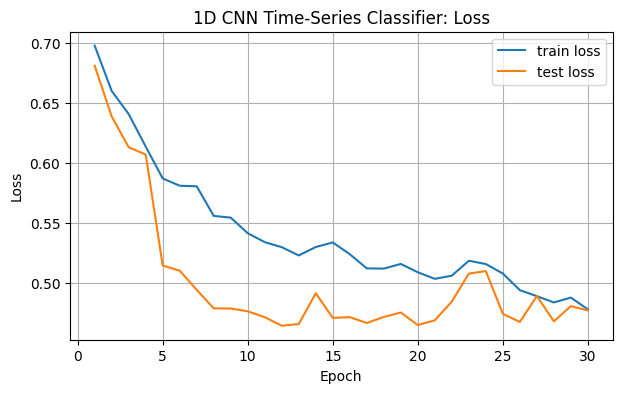

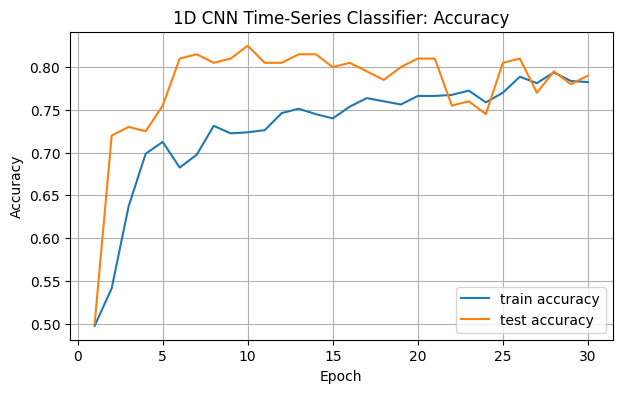

In [501]:
ts_model = TimeSeriesConvNet(sequence_length=2500, num_classes=2);
ts_history = train_classifier(
    ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=30,
    learning_rate=1.3e-3,
    verbose=True,
    enable_scheduler=False
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")

## 17. Model Performance Comparison

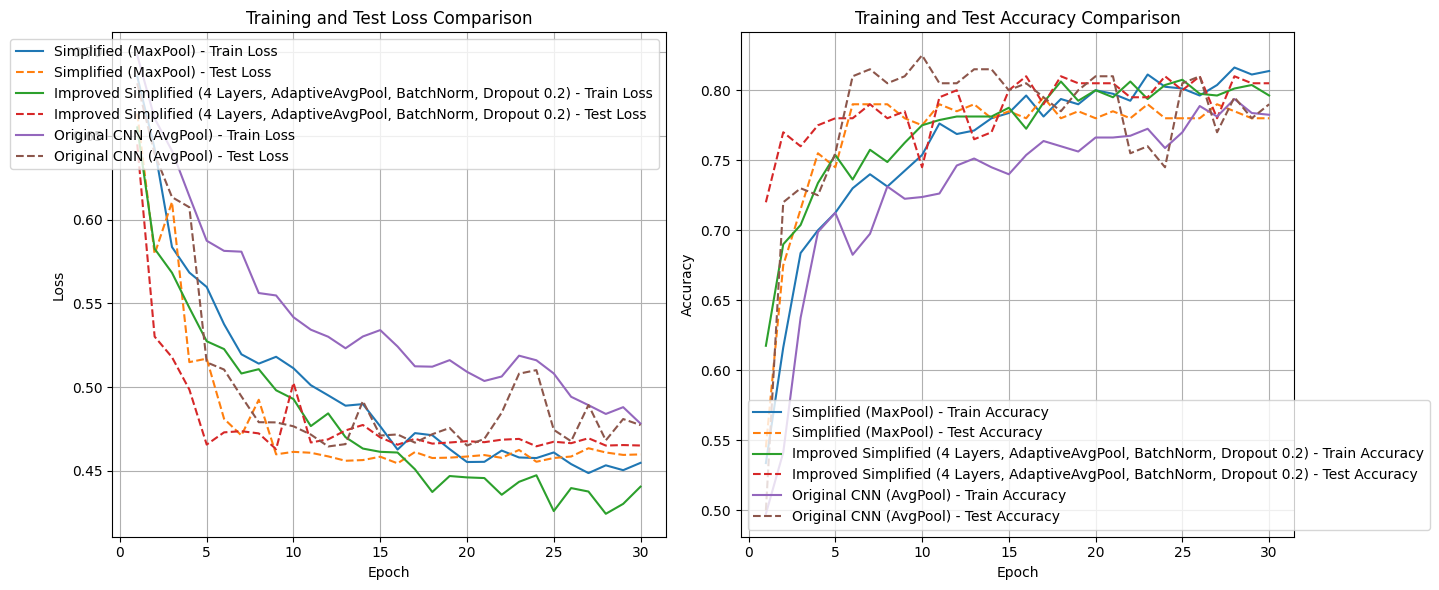

In [509]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_histories(histories_dict):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot Loss
    for model_name, history in histories_dict.items():
        epochs = np.arange(1, len(history['train_loss']) + 1)
        axes[0].plot(epochs, history['train_loss'], label=f'{model_name} - Train Loss', linestyle='-')
        if len(history['test_loss']) > 0:
            axes[0].plot(epochs, history['test_loss'], label=f'{model_name} - Test Loss', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Test Loss Comparison')
    axes[0].grid(True)
    axes[0].legend()

    # Plot Accuracy
    for model_name, history in histories_dict.items():
        epochs = np.arange(1, len(history['train_acc']) + 1)
        axes[1].plot(epochs, history['train_acc'], label=f'{model_name} - Train Accuracy', linestyle='-')
        if len(history['test_acc']) > 0:
            axes[1].plot(epochs, history['test_acc'], label=f'{model_name} - Test Accuracy', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Test Accuracy Comparison')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Collect all histories into a dictionary
all_histories = {
    "Simplified (MaxPool)": simplified_ts_history,
    "Improved Simplified (4 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.2)": improved_simplified_ts_history,
    "Original CNN (AvgPool)": ts_history
}

# Plot the combined histories
plot_all_histories(all_histories)


## 15. Inspect Time-Series Predictions


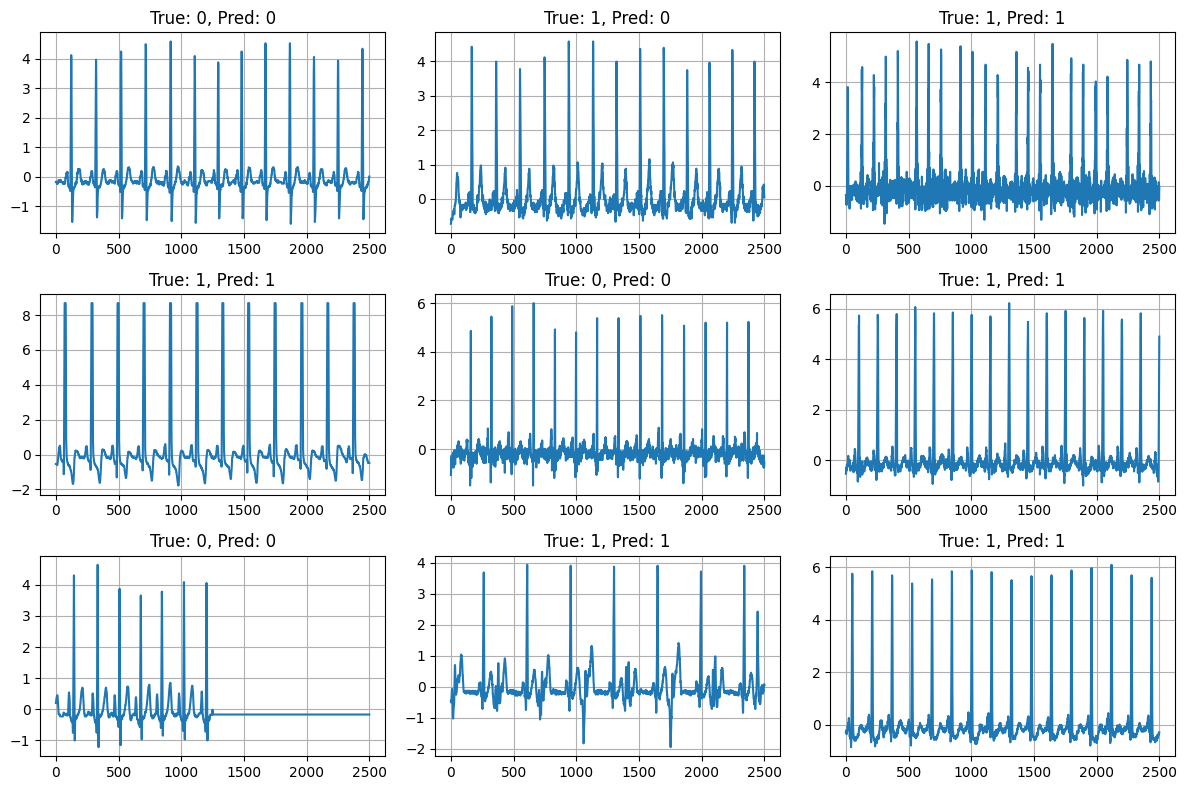

In [508]:
improved_ts_model.eval()

X_batch, y_batch = next(iter(ts_test_loader))

with torch.no_grad():
    logits = improved_ts_model(X_batch.to(device))
    predictions = torch.argmax(logits, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(X_batch[i, 0].numpy())
    plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
    plt.grid(True)

plt.tight_layout()
plt.show()


## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


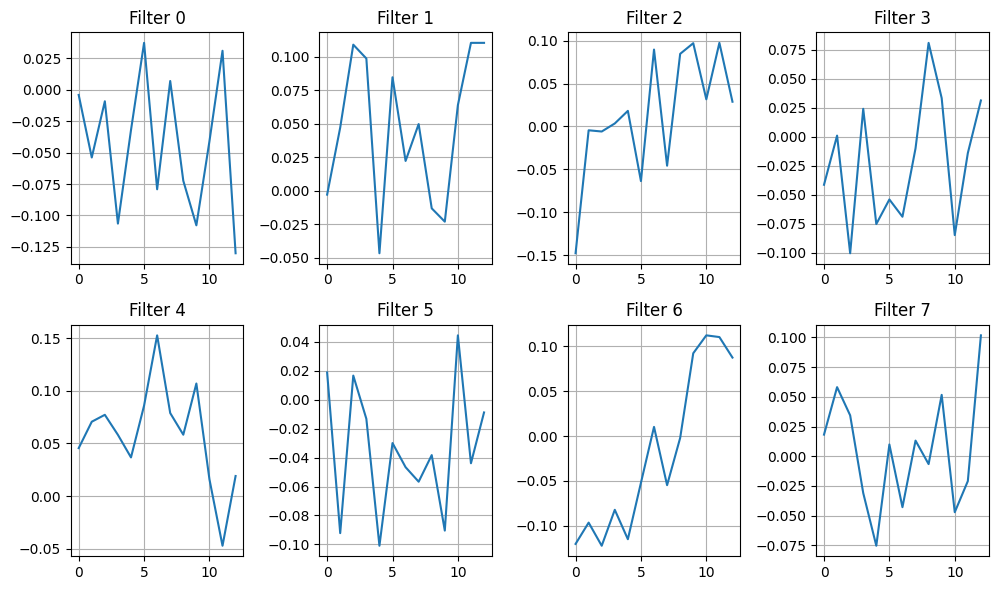

In [467]:

first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()




# Summary

This notebook showed two applications of convolutional neural networks in PyTorch.

## 2D CNN for MNIST

A 2D CNN uses filters that slide across image height and width. This is useful for image data because nearby pixels contain meaningful local structure.

## 1D CNN for Time Series

A 1D CNN uses filters that slide along the time axis. This is useful for detecting short temporal patterns such as oscillations, spikes, jumps, or repeated motifs.

## Key PyTorch Ideas

The most important PyTorch components were:

- `nn.Conv2d` for image convolution,
- `nn.Conv1d` for time-series convolution,
- `nn.ReLU` for nonlinear activation,
- `nn.MaxPool2d` and `nn.MaxPool1d` for downsampling,
- `nn.Linear` for dense classification layers,
- `nn.CrossEntropyLoss` for multiclass classification,
- `loss.backward()` for automatic backpropagation,
- `torch.optim.Adam` for parameter updates.

Compared with the NumPy implementation, PyTorch makes the neural network code much shorter because it handles gradients automatically.


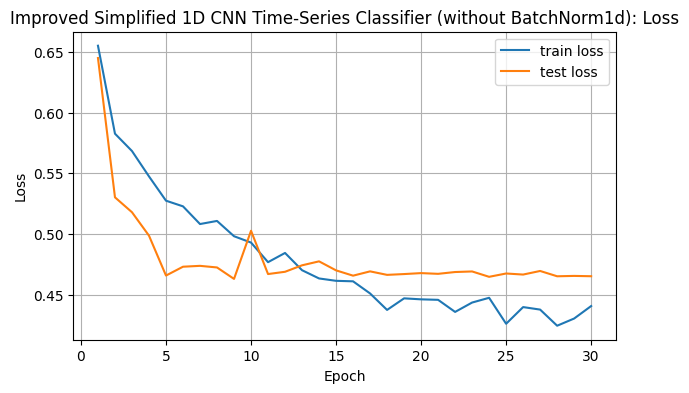

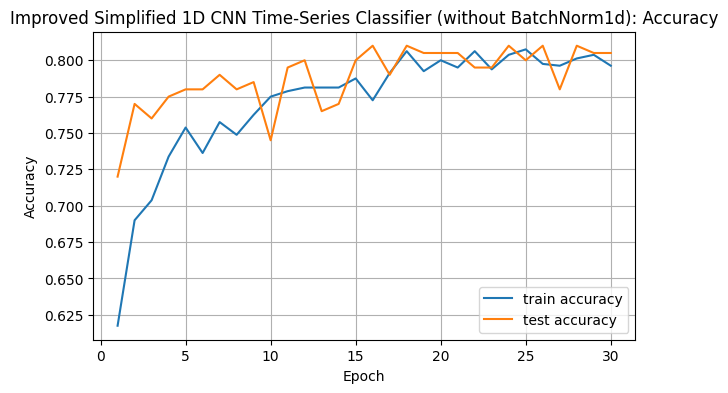

Saved experiment to /content/drive/MyDrive/REU_CNN_Experiments/20260630_151540


In [503]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, accuracy_score
from sklearn.calibration import calibration_curve
import torch.nn.functional as F

# ==================================================
# 1. SAVE DIRECTORY SETUP
# ==================================================
run_name = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = Path(f"/content/drive/MyDrive/REU_CNN_Experiments/{run_name}")
save_dir.mkdir(parents=True, exist_ok=True)

plots_dir = save_dir / "plots"
plots_dir.mkdir(exist_ok=True)

# ==================================================
# 2. EVALUATE MODEL AND GATHER PREDICTIONS
# ==================================================
# Assuming improved_ts_model is the model currently being worked on and trained
# and ts_test_loader is available from previous cells.

improved_ts_model.eval()
all_y_true = []
all_y_pred = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in ts_test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = improved_ts_model(X_batch)
        probs_batch = F.softmax(logits, dim=1)
        predictions_batch = torch.argmax(logits, dim=1)

        all_y_true.append(y_batch.cpu().numpy())
        all_y_pred.append(predictions_batch.cpu().numpy())
        all_probs.append(probs_batch.cpu().numpy())

y_true_test = np.concatenate(all_y_true)
y_pred = np.concatenate(all_y_pred)
probs = np.concatenate(all_probs)

# Calculate overall metrics
overall_accuracy = accuracy_score(y_true_test, y_pred)
metrics_demo = {'accuracy': overall_accuracy, 'num_samples': len(y_true_test)}

# ==================================================
# 3. SAVE MODEL + DATA
# ==================================================
# Save the improved model which is the active model
torch.save(improved_ts_model.state_dict(), save_dir / "model_weights.pth")
torch.save(improved_ts_model, save_dir / "full_model.pt")

pd.DataFrame([metrics_demo]).to_csv(save_dir / "metrics.csv", index=False)

cm = confusion_matrix(y_true_test, y_pred)

pd.DataFrame(
    cm,
    index=["True Neg", "True Pos"],
    columns=["Pred Neg", "Pred Pos"]
).to_csv(save_dir / "confusion_matrix.csv")

pd.DataFrame({
    "y_true": y_true_test,
    "y_pred": y_pred,
    "p_positive": probs[:, 1]
}).to_csv(save_dir / "predictions.csv", index=False)

# ==================================================
# 4. SAFE FIGURE SAVER
# ==================================================
def save_fig(fig, name):
    fig.savefig(plots_dir / name, bbox_inches="tight", dpi=300)
    plt.close(fig)

# ==================================================
# 5. PLOTTING FUNCTIONS (RETURN FIGURES — CRITICAL FIX)
# ==================================================

def plot_roc_curve(y_true, probs):
    fig, ax = plt.subplots()
    fpr, tpr, _ = roc_curve(y_true, probs)
    ax.plot(fpr, tpr, label="ROC")
    ax.plot([0, 1], [0, 1], "--")
    ax.set_title("ROC Curve")
    ax.legend()
    return fig


def plot_precision_recall_curve(y_true, probs):
    fig, ax = plt.subplots()
    precision, recall, _ = precision_recall_curve(y_true, probs)
    ax.plot(recall, precision)
    ax.set_title("Precision-Recall Curve")
    return fig


def plot_calibration_curve(y_true, probs, n_bins=10):
    fig, ax = plt.subplots()
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins)
    ax.plot(prob_pred, prob_true, marker="o")
    ax.set_title("Calibration Curve")
    return fig

# Define calibration_table function
def calibration_table(y_true, prob_pos, n_bins=10):
    bins = np.linspace(0., 1., n_bins + 1)
    bin_indices = np.digitize(prob_pos, bins)

    table_data = []
    for i in range(1, n_bins + 1):
        mask = bin_indices == i
        if np.any(mask):
            fraction_of_positives = np.mean(y_true[mask])
            mean_predicted_value = np.mean(prob_pos[mask])
            table_data.append({
                'bin': f'[{bins[i-1]:.2f}, {bins[i]:.2f})',
                'count': np.sum(mask),
                'fraction_of_positives': fraction_of_positives,
                'mean_predicted_value': mean_predicted_value
            })
    return pd.DataFrame(table_data)


def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig1, ax1 = plt.subplots(figsize=(7, 4))

    ax1.plot(epochs, history["train_loss"], label="train loss")

    if "test_loss" in history and len(history["test_loss"]) > 0:
        ax1.plot(epochs, history["test_loss"], label="test loss")

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(title + ": Loss")
    ax1.grid(True)
    ax1.legend()
    plt.show(fig1)

    fig2, ax2 = plt.subplots(figsize=(7, 4))

    ax2.plot(epochs, history["train_acc"], label="train accuracy")

    if "test_acc" in history and len(history["test_acc"]) > 0:
        ax2.plot(epochs, history["test_acc"], label="test accuracy")

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(title + ": Accuracy")
    ax2.grid(True)
    ax2.legend()
    plt.show(fig2)

    return fig1, fig2

# ==================================================
# 6. SAVE ALL PLOTS (NOW GUARANTEED NON-BLANK)
# ==================================================

fig = plot_roc_curve(y_true_test, probs[:, 1])
save_fig(fig, "roc_curve.png")

fig = plot_precision_recall_curve(y_true_test, probs[:, 1])
save_fig(fig, "precision_recall_curve.png")

fig = plot_calibration_curve(y_true_test, probs[:, 1], n_bins=10)
save_fig(fig, "calibration_curve.png")

# Use the improved_simplified_ts_history for plotting
fig1, fig2 = plot_history(improved_simplified_ts_history, title="Improved Simplified 1D CNN Time-Series Classifier (without BatchNorm1d)")

save_fig(fig1, "history_loss.png")
save_fig(fig2, "history_accuracy.png")

# ==================================================
# 7. EXTRA TABLE (CALIBRATION)
# ==================================================
calibration_table(y_true_test, probs[:, 1], n_bins=10).to_csv(
    save_dir / "calibration_table.csv",
    index=False
)

# ==================================================
# 8. DONE
# ==================================================
print(f"Saved experiment to {save_dir}")

## 1. Setup

In [469]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [470]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [471]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):
    """
    Collect labels and probabilities from a standard deterministic neural network.

    Args:
        model: PyTorch classifier returning logits of shape [batch_size, 2].
        data_loader: DataLoader yielding (x, y).
        device: torch device.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=-1)

        all_y.append(y.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

In [472]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [473]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [474]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [475]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [476]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [477]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [478]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [479]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [480]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

In [481]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):
    """
    Estimate negative ELBO per example for a Pyro Bayesian neural network.

    Args:
        model: Pyro model with forward(x, y=None, dataset_size=None).
        guide: Pyro guide.
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        dataset_size: Optional size used for minibatch scaling. If None, each batch
                      uses its own batch size, which is often appropriate for a
                      held-out evaluation estimate.

    Returns:
        negative_elbo_per_example: scalar float
    """
    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

In [482]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [483]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [504]:
ts_model.to(device)
simplified_ts_model.to(device)
improved_ts_model.to(device)

ts_metrics, ts_y_true, ts_probs, ts_y_pred = evaluate_standard_nn_classifier(
    model=ts_model,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

simplified_ts_metrics, simplified_ts_y_true, simplified_ts_probs, simplified_ts_y_pred = evaluate_standard_nn_classifier(
    model=simplified_ts_model,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

improved_simplified_ts_metrics, improved_simplified_ts_y_true, improved_simplified_ts_probs, improved_simplified_ts_y_pred = evaluate_standard_nn_classifier(
    model=improved_ts_model,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

comparison_df = pd.DataFrame(
    [
        ts_metrics,
        simplified_ts_metrics,
        improved_simplified_ts_metrics
    ],
    index=[
        "Original CNN (AvgPool)",
        "Simplified (MaxPool)",
        "Improved Simplified (4 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.2)"
    ]
).T

display(comparison_df)

,Original CNN (AvgPool),Simplified (MaxPool),"Improved Simplified (4 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.2)"
accuracy,0.790000,0.780000,0.805000
balanced_accuracy,0.790000,0.780000,0.805000
auroc,0.850400,0.869300,0.857600
auprc,0.858442,0.874361,0.868342
sensitivity,0.730000,0.700000,0.750000
specificity,0.850000,0.860000,0.860000
negative_log_likelihood,0.477346,0.459864,0.465177
brier_score,0.155057,0.148328,0.151201
expected_calibration_error,0.023880,0.036422,0.061690
tn,85.000000,86.000000,86.000000


Confusion matrix [[TN, FP], [FN, TP]]:
[[89 11]
 [37 63]]


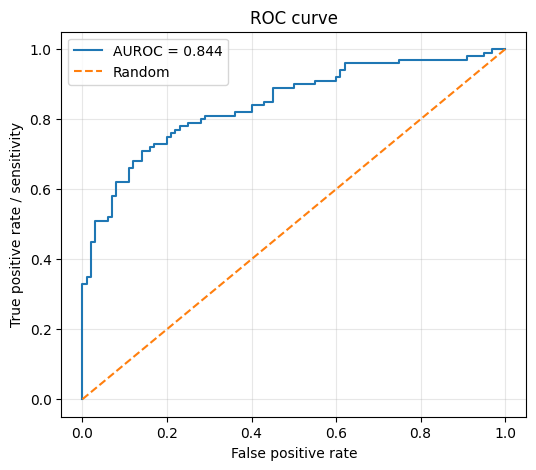

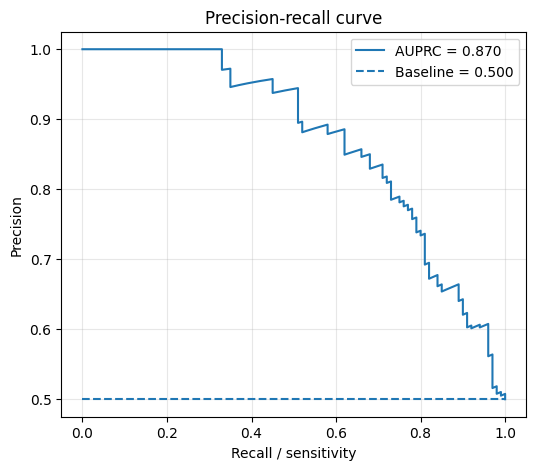

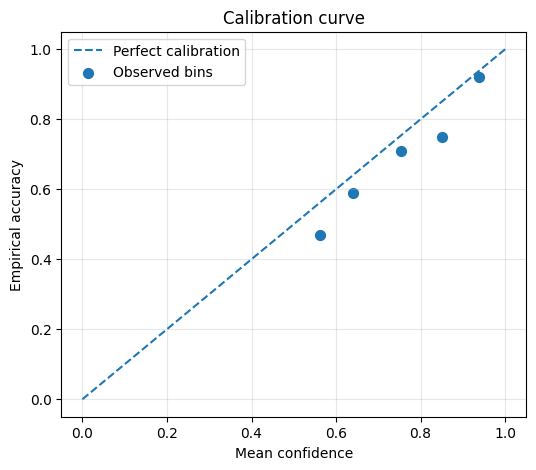

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,17,0.561044,0.470588,0.090455
6,7,0.6,0.7,17,0.639068,0.588235,0.050833
7,8,0.7,0.8,38,0.753450,0.710526,0.042924
8,9,0.8,0.9,64,0.850177,0.750000,0.100177
9,10,0.9,1.0,64,0.937680,0.921875,0.015805


In [485]:

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred, labels=[0, 1]))

plot_roc_curve(y_true_test, probs)
plot_precision_recall_curve(y_true_test, probs)
plot_calibration_curve(y_true_test, probs, n_bins=10)
calibration_table(y_true_test, probs, n_bins=10)


## 19. How to use this with your ECG standard neural network

If you have a standard PyTorch CNN called `standard_cnn`, use:

```python
standard_metrics, standard_y, standard_probs, standard_pred = evaluate_standard_nn_classifier(
    model=standard_cnn,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

pd.DataFrame([standard_metrics], index=["standard CNN"])
```

The model must return logits of shape `[batch_size, 2]`.

## 20. How to use this with your ECG Bayesian neural network

If you have a Bayesian CNN called `bcnn` and guide called `bcnn_guide`, use:

```python
bayes_metrics, bayes_y, bayes_probs, bayes_pred = evaluate_bayesian_nn_classifier(
    model=bcnn,
    guide=bcnn_guide,
    data_loader=ts_test_loader,
    device=device,
    num_samples=100,
    n_bins=10,
    dataset_size=None,
)

pd.DataFrame([bayes_metrics], index=["Bayesian CNN"])
```

For training ELBO during minibatch training, `dataset_size` should usually be the full training-set size:

```python
train_dataset_size = len(ts_train_loader.dataset)
```

For held-out test-set reporting, using `dataset_size=None` gives an evaluation-style per-example estimate on the batches being evaluated.

## 21. Comparing a standard classifier and Bayesian classifier

Once both models have been evaluated, compare them side-by-side:

```python
comparison = pd.DataFrame(
    [standard_metrics, bayes_metrics],
    index=["standard CNN", "Bayesian CNN"],
)

comparison.T
```

Interpretation guidance:

| Metric | Better direction | What it emphasizes |
|---|---:|---|
| negative ELBO | lower | Bayesian posterior fit plus prior regularization |
| accuracy | higher | Overall hard-decision correctness |
| balanced accuracy | higher | Average performance across positive and negative classes |
| AUROC | higher | Ranking positives above negatives |
| AUPRC | higher | Positive-class retrieval, especially with imbalance |
| sensitivity | higher | Avoiding false negatives |
| specificity | higher | Avoiding false positives |
| negative log likelihood | lower | Probabilistic correctness; punishes confident errors |
| Brier score | lower | Mean squared probability error |
| expected calibration error | lower | Agreement between confidence and empirical accuracy |

For a medical classifier, raw accuracy is rarely enough. A Bayesian classifier may have similar accuracy to a standard classifier but better NLL, Brier score, ECE, or uncertainty behavior. That can still be valuable if uncertainty is clinically important.

## 22. Practical notes for Bayesian classifiers

### Use enough posterior samples

Bayesian predictions can be noisy if `num_samples` is small. For final evaluation, try values such as:

```python
num_samples = 100
num_samples = 250
num_samples = 500
```

and check whether the metrics stabilize.

### Calculate metrics from averaged probabilities

For Bayesian classifiers, do not calculate metrics from a single sampled network unless you specifically want to analyze one posterior draw. Usually, use:

$$
\bar p_i = \frac{1}{S}\sum_{s=1}^S p(y_i=1 \mid x_i, \theta^{(s)}).
$$

Then calculate accuracy, AUROC, AUPRC, NLL, Brier score, and ECE from \(\bar p_i\).

### Do not expect ELBO and accuracy to move identically

Negative ELBO optimizes probabilistic fit plus a KL penalty. Accuracy is a thresholded hard-decision metric. They are related but not equivalent.

### Report class prevalence

AUPRC and accuracy are easier to interpret when you also report:

$$
P(y=1).
$$

This notebook includes `positive_prevalence` in the metrics dictionary.